# API Kald figur 1 og 2

In [1]:
import requests
import json

# API endpoint
url = "https://www.krl.dk/sirka/sirkaApi/tableApi"

# API request payload
payload = {
    "apiKey": "b6caa39c5a6dc520a83ed1624a7bdfdd1935d9fb2bee1d5e2c14dc08ee4ea57ceacca8e9550f5b25ad07b745a612d4b6b5b07bd781baff0908b5891c0beb65c1",
    "table": "Personale-måned",
    "time": [
        {"y1": "2026", "m1": "01"},
        {"y1": "2025", "m1": "01"},
        {"y1": "2024", "m1": "01"},
        {"y1": "2023", "m1": "01"},
        {"y1": "2022", "m1": "01"},
        {"y1": "2021", "m1": "01"},
        {"y1": "2020", "m1": "01"},
        {"y1": "2019", "m1": "01"},
        {"y1": "2018", "m1": "01"},
    ],
    "control": ["kom_reg"],
    "data": ["fuldtid"],
    "selection": [
        {
            "name": "Udvalgte population",
            "filters": {
                "omr": ["1", "8"]
            }
        }
    ],
    "options": {
        "totals": True,
        "actions": [],
        "tableName": "Antal ansatte",
        "subLimit": 5,
        "modelName": "SIRKA",
        "timeIncreasing": True
    },
    "dimension": {
        "viewportHeight": 812,
        "viewportWidth": 1440,
        "xsMaxWidth": 768,
        "smMaxWidth": 992,
        "mdMaxWidth": 1200,
        "CONSTANTS": {
            "XS": 0,
            "SM": 1,
            "MD": 2,
            "LG": 3,
            "MAIL": 4
        }
    }
}

# Send POST request
response = requests.post(url, json=payload)


# Figur 1

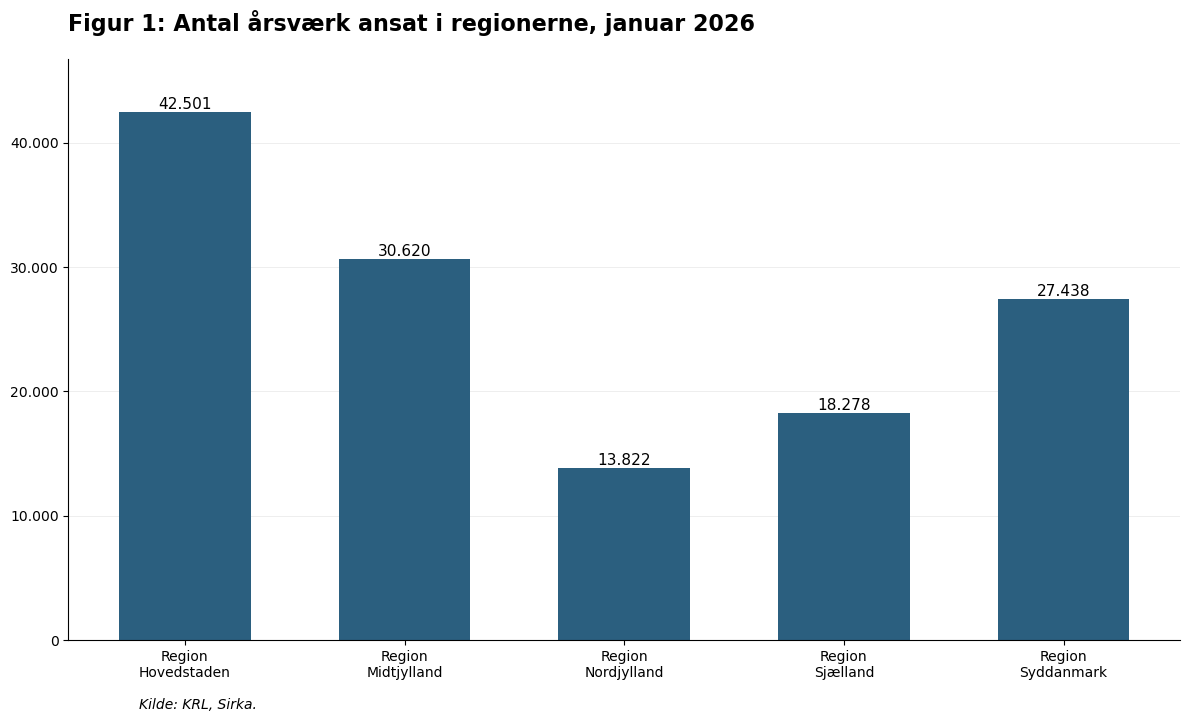

In [2]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Hent data fra API
api_data = response.json()

# Map regionskoder til regionsnavne
region_map = {
    '081': 'Region\nNordjylland',
    '082': 'Region\nMidtjylland',
    '083': 'Region\nSyddanmark',
    '084': 'Region\nHovedstaden',
    '085': 'Region\nSjælland'
}

# Find den nyeste måned
items_med_ym = [item for item in api_data if '_YM' in item and item['_YM']]
nyeste_maaned = max(item['_YM'] for item in items_med_ym)

# Filtrer data for den nyeste måned
nyeste_data = [item for item in items_med_ym if item['_YM'] == nyeste_maaned]

# Opbyg dict med data
data_dict = {item['kom_reg']: item['fuldtid'] for item in nyeste_data if item.get('kom_reg') in region_map}

# Udtræk i ønsket rækkefølge: Hovedstaden, Midtjylland, Nordjylland, Sjælland, Syddanmark
region_ordre = ['084', '082', '081', '085', '083']
regioner = [region_map[kode] for kode in region_ordre if kode in data_dict]
årsværk = [data_dict[kode] for kode in region_ordre if kode in data_dict]

# Opret figuren
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(regioner, årsværk, color='#2B5F7F', width=0.6)

# Tilføj værdier på toppen af søjlerne
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{round(height):,}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=11, fontweight='normal')

# Styling
ax.set_ylim(0, max(årsværk) * 1.1)
ax.set_ylabel('', fontsize=11)
ax.set_xlabel('', fontsize=11)

# Formater månedsnavn til titel
aar = nyeste_maaned[:4]
maaned_nummer = nyeste_maaned[4:]
maaneder = {
    '01': 'januar', '02': 'februar', '03': 'marts', '04': 'april',
    '05': 'maj', '06': 'juni', '07': 'juli', '08': 'august',
    '09': 'september', '10': 'oktober', '11': 'november', '12': 'december'
}
maaned_navn = maaneder.get(maaned_nummer, maaned_nummer)

ax.set_title(f'Figur 1: Antal årsværk ansat i regionerne, {maaned_navn} {aar}', 
             fontsize=16, fontweight='bold', pad=20, loc='left')

# Y-akse formatting
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

# Grid styling
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Fjern top og højre ramme
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout og kilde
plt.tight_layout()
plt.figtext(0.12, -0.02, 'Kilde: KRL, Sirka.', fontsize=10, style='italic')

plt.show()

# Figur 2

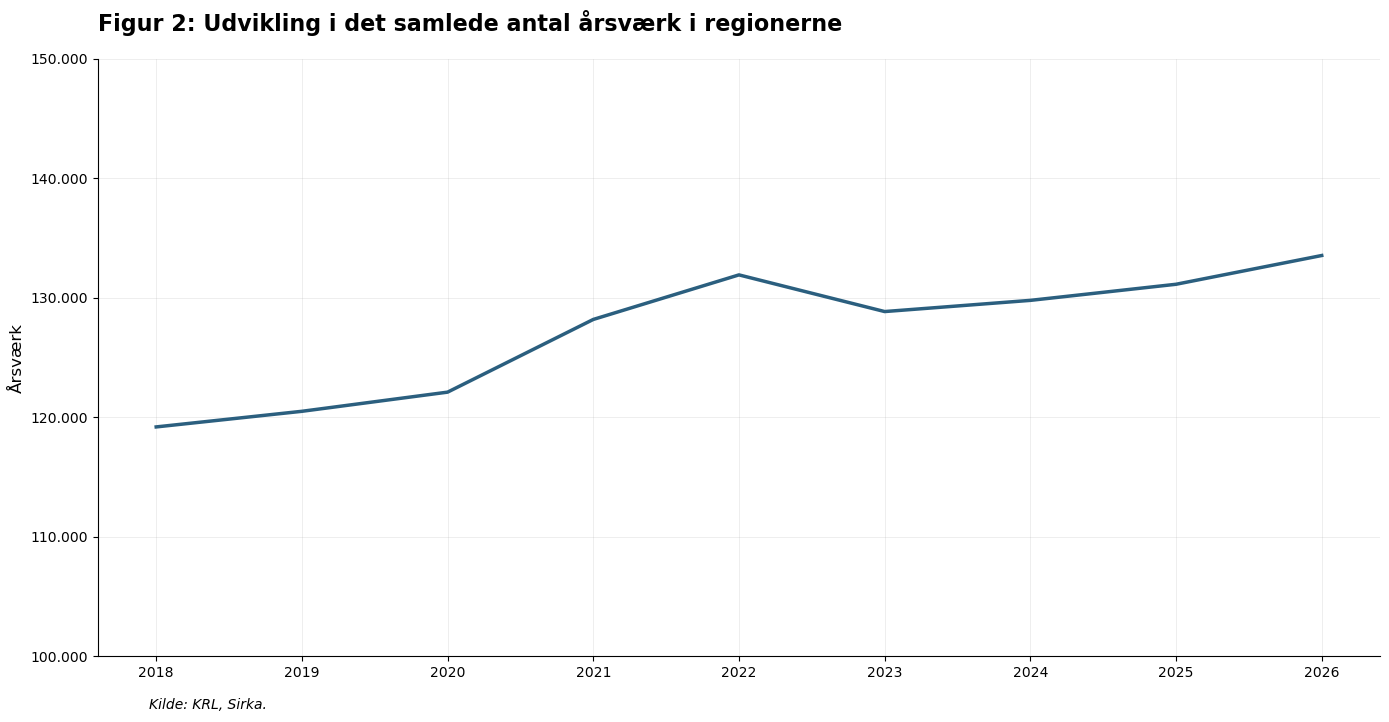

In [3]:

# Hent data fra API
api_data = response.json()

# Filtrer kun total rækker (dem hvor kom_reg er None og med "Udvalgte population")
total_items = [item for item in api_data 
               if '_YM' in item 
               and item['_YM'] 
               and item.get('kom_reg') is None
               and item.get('_BM') == 'Udvalgte population']

# Opret serie med totaler
df_total = pd.DataFrame(total_items)
monthly_totals = df_total.set_index('_YM')['fuldtid'].sort_index()

# Udtræk kun januar måneder
years = []
values = []
for ym, value in monthly_totals.items():
    if ym.endswith('01'):  # Kun januar
        years.append(int(ym[:4]))
        values.append(value)

# Opret figur
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(years, values, color='#2B5F7F', linewidth=2.5)

# Styling
ax.set_ylim(100000, 150000)
ax.set_ylabel('Årsværk', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_title('Figur 2: Udvikling i det samlede antal årsværk i regionerne', 
             fontsize=16, fontweight='bold', pad=20, loc='left')

# Y-akse formatting
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

# Grid styling
ax.grid(axis='both', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Fjern top og højre ramme
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-aksen med årstal
ax.set_xticks(years)
ax.set_xticklabels(years)

# Layout og kilde
plt.tight_layout()
plt.figtext(0.11, -0.02, 'Kilde: KRL, Sirka.', 
            fontsize=10, style='italic')

plt.show()



# API kald figur 3

In [10]:
import requests
import json

# API endpoint
url = "https://www.krl.dk/sirka/sirkaApi/tableApi"

# API request payload
payload = {
    "apiKey": "b6caa39c5a6dc520a83ed1624a7bdfdd1935d9fb2bee1d5e2c14dc08ee4ea57ceacca8e9550f5b25ad07b745a612d4b6b5b07bd781baff0908b5891c0beb65c1",
    "table": "Personale-måned",
    "time": [
        {"y1": "2025", "m1": "02"},
        {"y1": "2024", "m1": "02"},
        {"y1": "2023", "m1": "02"},
        {"y1": "2022", "m1": "02"},
        {"y1": "2021", "m1": "02"},
    ],
    "control": ["overenskomst", "stilling", "klassificering"],
    "data": ["fuldtid"],
    "selection": [
        {
            "name": "Udvalgte population",
            "filters": {
                # Koder som matcher grupperne i Figur 3
                "trs": [
                    # Akademikere
                    "272",
                    # Læger (066)
                    "066", "06609", "06608", "06610", "06618", "06611", "06620", "06617", "06605", "06606",
                    # Læger (113)
                    "113", "11304", "11310", "11301", "11308",
                    # Ledende sygeplejersker
                    "301", "30101",
                    # Sygeplejersker
                    "300", "30001", "30023", "30024", "3002302", "3002402",
                    # Jordemødre
                    "296", "29608", "29601", "29610", "2960103", "2961003",
                    # Fysioterapeuter
                    "29605", "2960102", "2961002",
                    # Ergoterapeuter
                    "29602", "2960101", "2961001",
                    # Social- og sundhedsassistenter
                    "283", "28305",
                    # Sundhedsadministrativt personale
                    "055", "05518", "05513", "05514", "05519",
                    # Socialpædagoger
                    "078", "07801",
                    # Omsorgs- og pædagogmedhjælpere m.fl.
                    "293",
                    # Sygehusportører
                    "072",
                    # Rengørings- og husassistenter
                    "284", "28401", "289", "28901",
                    # Erhvervsuddannede serviceassistenter
                    "285",
                ],
                "omr": ["1", "8"],
            },
        },
    ],
    "options": {
        "totals": True,
        "actions": [],
        "tableName": "Antal ansatte",
        "subLimit": 5,
        "modelName": "SIRKA",
        "timeIncreasing": True,
    },
    "dimension": {
        "viewportHeight": 812,
        "viewportWidth": 1440,
        "xsMaxWidth": 768,
        "smMaxWidth": 992,
        "mdMaxWidth": 1200,
        "CONSTANTS": {
            "XS": 0,
            "SM": 1,
            "MD": 2,
            "LG": 3,
            "MAIL": 4,
        },
    },
}

# Send POST request
response_groups = requests.post(url, json=payload)

# Check response and show a preview (first 5 rows)
if response_groups.status_code == 200:
    api_data_groups = response_groups.json()
    if isinstance(api_data_groups, list):
        print("Success! Data retrieved (preview):")
        print(f"Rows: {len(api_data_groups)}")
        for i, item in enumerate(api_data_groups[:5]):
            print(f"Row {i+1}: {item}")
    else:
        print("Success! Data retrieved (preview):")
        print(json.dumps(api_data_groups, indent=2, ensure_ascii=False)[:2000])
else:
    print(f"Error: {response_groups.status_code}")
    print(response_groups.text)

Success! Data retrieved (preview):
Rows: 1627
Row 1: {'_YM': '202102', '_BM': 'Udvalgte population', 'overenskomst': '055', 'stilling': '05501', 'klassificering': '0550101', 'fuldtid': 349.92754737120237}
Row 2: {'_YM': '202102', '_BM': 'Udvalgte population', 'overenskomst': '055', 'stilling': '05501', 'klassificering': None, 'fuldtid': 349.92754737120237}
Row 3: {'_YM': '202102', '_BM': 'Udvalgte population', 'overenskomst': '055', 'stilling': '05503', 'klassificering': '0550301', 'fuldtid': 68.38222857142857}
Row 4: {'_YM': '202102', '_BM': 'Udvalgte population', 'overenskomst': '055', 'stilling': '05503', 'klassificering': '0550302', 'fuldtid': 457.2350278682816}
Row 5: {'_YM': '202102', '_BM': 'Udvalgte population', 'overenskomst': '055', 'stilling': '05503', 'klassificering': None, 'fuldtid': 525.6172564397103}


# Figur 3

In [14]:
# Helperfunktioner + gruppedefinitioner til personalegrupper (lagt i en .py-fil for at gøre notebooken kortere)
import sys
from pathlib import Path
import importlib

# Sørg for at mappen med 'personalegrupper.py' er på Python path
this_dir = Path.cwd()
if str(this_dir) not in sys.path:
    sys.path.insert(0, str(this_dir))

# Vigtigt: reload så ændringer i personalegrupper.py slår igennem uden kernel-restart
import personalegrupper as pg
pg = importlib.reload(pg)

combo_groups = pg.COMBO_GROUPS
groups = pg.GROUP_SPECS
order = pg.ORDER
sum_group_for_ym = pg.sum_group_for_ym
sum_matches_for_ym = pg.sum_matches_for_ym
sum_overenskomst_total_for_ym = pg.sum_overenskomst_total_for_ym

In [15]:
# Beregn personalegrupper for februar 2021-2025 (Output: bred tabel + %-vis ændring 2021→2025)
import pandas as pd

rows = api_data_groups  # fra API-kaldet i cellen ovenfor
years = [2021, 2022, 2023, 2024, 2025]
month = "02"

table: dict[str, dict[int, float]] = {}
for group_name in order:
    spec = groups.get(group_name)
    row: dict[int, float] = {}
    for year in years:
        ym = f"{year}{month}"
        if group_name in combo_groups:
            total = sum_matches_for_ym(rows, ym, combo_groups[group_name])
        elif group_name == "Rengørings- og husassistenter":
            total = 0.0
            total += sum_group_for_ym(rows, ym, overenskomst="284", stillinger=["28401"], klassificeringer=None, klass_none_mode="require")
            total += sum_group_for_ym(rows, ym, overenskomst="289", stillinger=["28901"], klassificeringer=None, klass_none_mode="require")
        else:
            if spec["klass_none_mode"] == "overenskomst_total":
                total = sum_overenskomst_total_for_ym(rows, ym, overenskomst=spec["overenskomst"])
            else:
                total = sum_group_for_ym(
                    rows,
                    ym,
                    overenskomst=spec["overenskomst"],
                    stillinger=spec["stillinger"],
                    klassificeringer=spec["klassificeringer"],
                    klass_none_mode=spec["klass_none_mode"],
                )
        row[year] = float(total)
    table[group_name] = row

df = pd.DataFrame.from_dict(table, orient="index")[years]
df = df.round(0).astype(int)

# %-vis ændring fra 2021 til 2025
base = df[2021].replace(0, pd.NA)
pct = ((df[2025] - df[2021]) / base) * 100
pct = pct.round(1)

df_out = df.copy()
df_out["%-vis ændring\nfra 2021 til 2025"] = pct

def fmt_int(x: int) -> str:
    return f"{x:,}".replace(",", ".")

def fmt_pct(x) -> str:
    if pd.isna(x):
        return ""
    # dansk decimal-komma
    return f"{x:.1f}".replace(".", ",")

df_formatted = df_out.copy()
for y in years:
    df_formatted[y] = df_out[y].map(fmt_int)
df_formatted["%-vis ændring\nfra 2021 til 2025"] = df_out["%-vis ændring\nfra 2021 til 2025"].map(fmt_pct)

display(df_formatted)

,2021,2022,2023,2024,2025,%-vis ændring\nfra 2021 til 2025
Akademikere,9.181,9.720,9.977,10.098,10.614,"15,6"
Lægelige chefer,1.084,1.105,1.454,1.619,1.662,"53,3"
Overlæger,5.341,5.405,5.054,4.962,4.958,"-7,2"
Speciallæger,2.687,2.775,2.834,2.883,2.983,"11,0"
Uddannelseslæger,8.453,8.569,8.638,8.861,9.223,"9,1"
Ledende sygeplejersker,2.020,2.034,2.026,2.018,1.968,"-2,6"
Sygeplejersker,35.099,35.132,34.639,35.325,35.680,"1,7"
Jordemødre,1.685,1.662,1.741,1.840,1.880,"11,6"
Fysioterapeuter,2.021,2.105,2.132,2.055,2.036,"0,7"
Ergoterapeuter,1.241,1.316,1.342,1.320,1.288,"3,8"


# Figur 4

In [16]:
# Figur 4: Personale-måned (Beskæftigelsesgrad-variabler) for samme grupper som Figur 3, februar 2021-2025
import requests
import json

url = "https://www.krl.dk/sirka/sirkaApi/tableApi"
api_key = "b6caa39c5a6dc520a83ed1624a7bdfdd1935d9fb2bee1d5e2c14dc08ee4ea57ceacca8e9550f5b25ad07b745a612d4b6b5b07bd781baff0908b5891c0beb65c1"

# Samme 'trs' (grupper/koder) som i Figur 3-kaldet
trs_codes = [
    "272",
    "066", "06609", "06610", "06608", "06618", "06611", "06620", "06617",
    "06605", "06606", "06006",
    "113", "11304", "11310", "11301", "11308",
    "301", "30101",
    "300", "30001", "30023", "30024", "3002302", "3002402",
    "296", "29608", "29601", "29610", "2960103", "2961003",
    "29605", "2960102", "2961002",
    "29602", "2960101", "2961001",
    "283", "28305",
    "055", "05518", "05513", "05514", "05519",
    "078", "07801",
    "293",
    "072",
    "284", "28401", "289", "28901",
    "285",
 ]

time = [
    {"y1": "2021", "m1": "02"},
    {"y1": "2022", "m1": "02"},
    {"y1": "2023", "m1": "02"},
    {"y1": "2024", "m1": "02"},
    {"y1": "2025", "m1": "02"},
 ]

payload_beskaeft = {
    "apiKey": api_key,
    "table": "Personale-måned",
    "time": time,
    "control": ["overenskomst", "stilling", "klassificering"],
    "data": [
        "hoveder", "bhhel", "bhdel", "bhid1", "bhid2", "bhid3", "bhid4",
        "bpt", "gnsalle", "gnsmnd", "gnsdel",
    ],
    "selection": [
        {
            "name": "Udvalgte population",
            "filters": {
                "trs": trs_codes,
                "trb": ["1", "2"],
                "afl": ["0", "1"],
                "omr": ["1", "8"],
            },
        }
    ],
    "options": {
        "totals": True,
        "actions": [],
        "tableName": "Beskæftigelsesgrad",
        "subLimit": 5,
        "modelName": "SIRKA",
        "timeIncreasing": True,
        # Vigtigt: kræves af tabellen for at udfylde <#bi*> tags i serverens SQL
        "tagValues": [
            {"name": "bi1", "dsql": 31},
            {"name": "bi2", "dsql": 27},
            {"name": "bi3", "dsql": 19},
            {"name": "bi1_1", "dsql": 32},
            {"name": "bi2_1", "dsql": 28},
            {"name": "bi3_1", "dsql": 20},
        ],
    },
    "dimension": {
        "viewportHeight": 812,
        "viewportWidth": 1440,
        "xsMaxWidth": 768,
        "smMaxWidth": 992,
        "mdMaxWidth": 1200,
        "CONSTANTS": {"XS": 0, "SM": 1, "MD": 2, "LG": 3, "MAIL": 4},
    },
}

response_beskaeft = requests.post(url, json=payload_beskaeft, timeout=60)
print("HTTP:", response_beskaeft.status_code)
print("Content-Type:", response_beskaeft.headers.get("content-type"))

api_data_beskaeft = response_beskaeft.json()
print("Success! Data retrieved (preview):")
if isinstance(api_data_beskaeft, list):
    print("Rows:", len(api_data_beskaeft))
    for i, item in enumerate(api_data_beskaeft[:5]):
        print(f"Row {i+1}: {item}")
else:
    print(json.dumps(api_data_beskaeft, indent=2, ensure_ascii=False)[:2000])

HTTP: 200
Content-Type: application/json; charset=utf-8
Success! Data retrieved (preview):
{
  "error": "Error: Query failed: ER_BAD_FIELD_ERROR: Unknown column 'o.stk_p' in 'SELECT'"
}


# Figur 5: Beskæftigelsesgrad (samme grupper som Figur 3, februar 2021-2025)

In [8]:
# Figur 5: Fravær Årsstatistik (samme grupper som Figur 3)
import requests
import json

# API endpoint
url = "https://www.krl.dk/sirka/sirkaApi/tableApi"
api_key = "b6caa39c5a6dc520a83ed1624a7bdfdd1935d9fb2bee1d5e2c14dc08ee4ea57ceacca8e9550f5b25ad07b745a612d4b6b5b07bd781baff0908b5891c0beb65c1"

# Samme gruppe-koder som i Figur 3 (bruges her som trs_aar-frav til fraværstabellen)
trs_aar_frav_codes = [
    # Akademikere
    "272",
    # Lægelige chefer / læger
    "066", "06609", "06610", "06608", "06618", "06611", "06620", "06617",
    "06605", "06606", "06006",
    "113", "11304", "11310", "11301", "11308",
    # Ledende sygeplejersker
    "301", "30101",
    # Sygeplejersker
    "300", "30001", "30023", "30024", "3002302", "3002402",
    # Jordemødre
    "296", "29608", "29601", "29610", "2960103", "2961003",
    # Fysioterapeuter
    "29605", "2960102", "2961002",
    # Ergoterapeuter
    "29602", "2960101", "2961001",
    # Social- og sundhedsassistenter
    "283", "28305",
    # Sundhedsadministrativt personale
    "055", "05518", "05513", "05514", "05519",
    # Socialpædagoger
    "078", "07801",
    # Omsorgs- og pædagogmedhjælpere m.fl.
    "293",
    # Sygehusportører
    "072",
    # Rengørings- og husassistenter
    "284", "28401", "289", "28901",
    # Erhvervsuddannede serviceassistenter
    "285",
 ]

payload_fravaer = {
    "apiKey": api_key,
    "table": "Fravær Årsstatistik",
    "time": [{"y1": "2024"}],
    "control": ["overenskomst", "stilling", "klassificering", "kom_reg"],
    "data": ["f_fuld", "f_dag", "f_dp"],
    "selection": [
        {
            "name": "Udvalgte population",
            "filters": {
                "trs_aar-frav": trs_aar_frav_codes,
                "omr": ["1", "8"],
                "lif": ["10101", "10103", "10191", "10102"],
            },
        },
    ],
    "options": {
        "totals": True,
        "actions": [],
        "tableName": "Fravær - Årligt",
        "subLimit": 5,
        "modelName": "Fravær",
        "timeIncreasing": False,
        "hideTimeline": 1,
    },
    "dimension": {
        "viewportHeight": 763,
        "viewportWidth": 1420,
        "xsMaxWidth": 768,
        "smMaxWidth": 992,
        "mdMaxWidth": 1200,
        "CONSTANTS": {"XS": 0, "SM": 1, "MD": 2, "LG": 3, "MAIL": 4},
    },
}

response_fravaer = requests.post(url, json=payload_fravaer, timeout=60)
print("HTTP:", response_fravaer.status_code)
print("Content-Type:", response_fravaer.headers.get("content-type"))

api_data_fravaer = response_fravaer.json()
print("Success! Data retrieved (preview):")
if isinstance(api_data_fravaer, list):
    print(f"Rows: {len(api_data_fravaer)}")
    for i, item in enumerate(api_data_fravaer[:5]):
        print(f"Row {i+1}: {item}")
else:
    print(json.dumps(api_data_fravaer, indent=2, ensure_ascii=False)[:2000])

HTTP: 200
Content-Type: application/json; charset=utf-8
Success! Data retrieved (preview):
{
  "error": "Error: Servererror: selection"
}
